Output directory created: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB
Checking for existing results in: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB

No existing results found. Proceeding with classification...
All outputs will be saved to: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB
Processing: B2-101-2024AA_RGB

Found 3 training classes:
  Class 1: fire4coniferousforestdrawn - 8 polygons (color: #006400)
  Class 2: fire4fieldagriculturedrawn - 7 polygons (color: #FFD700)
  Class 3: fire4urbanbuiltupbareterritoriesdrawn - 5 polygons (color: #808080)

Total training polygons: 20
Number of classes: 3
Class mapping saved to: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB\B2-101-2024AA_RGB_class_names.pkl

TRUE OBJECT-BASED CLASSIFICATION - MEMORY EFFICIENT

Extracting training objects...
Pro

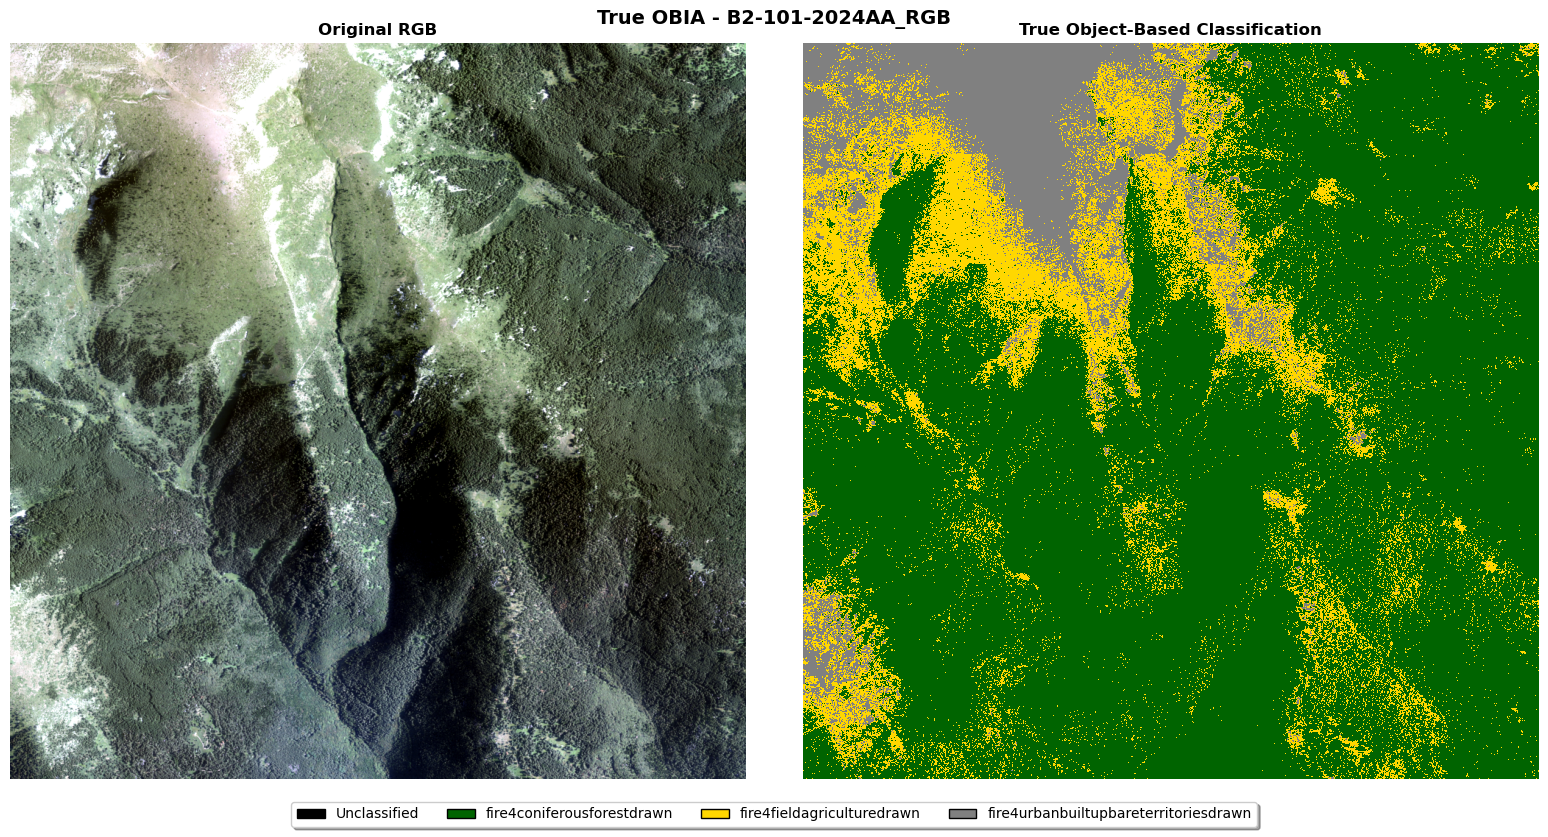


All results saved to: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB
Output files:
  - Classified raster: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB\B2-101-2024AA_RGB_obia_true.tif
  - Classification visualization: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB\B2-101-2024AA_RGB_obia_true.png
  - Class mapping: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB\B2-101-2024AA_RGB_class_names.pkl
  - Model: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB\B2-101-2024AA_RGB_model.pkl
  - Scaler: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB\B2-101-2024AA_RGB_scaler.pkl
  - Training data: C:\Users\steph\Downloads\master_thesis\exports\object_classification_results\B2-101-2024AA_RGB\B2-101-2024AA_RGB_trainin

0.324775936

In [2]:

# =============================================================================
# English: Object-based image classification script (OBIA) with supervised Random Forest.
# Bulgarian: Скрипт за обектно-базирана класификация на изображения (OBIA) с Random Forest.
# =============================================================================

import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
from skimage import segmentation, measure
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
import os
import gc
import time
import psutil
import pickle

# English: Disable all parallel processing to keep memory usage low.
# Bulgarian: Изключване на всички паралелни изчисления за по-ниска памет.
os.environ['JOBLIB_MULTIPROCESSING'] = '0'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

# English: File paths
# Bulgarian: Пътища до файлове
tif_path = r"C:\Users\steph\Downloads\master_thesis\input\high_resolution_data\B2-101-2024AA_RGB.tif"
polygons_dir = r"C:\Users\steph\Downloads\master_thesis\exports\object_classification_supervised"
base_output_dir = r"C:\Users\steph\Downloads\master_thesis\exports\object_classification_results"

# English: Create output folder based on the input image name.
# Bulgarian: Създаване на изходна папка на база името на входното изображение.
tif_basename = os.path.basename(tif_path).replace('.tif', '')
output_dir = os.path.join(base_output_dir, tif_basename)
os.makedirs(output_dir, exist_ok=True)

print(f"Output directory created: {output_dir}")

def print_memory_usage():
    # English: Print current memory usage in GB.
    # Bulgarian: Извеждане на текущото използване на памет в GB.
    process = psutil.Process()
    memory_gb = process.memory_info().rss / 1e9
    print(f"Memory usage: {memory_gb:.2f} GB")
    return memory_gb

def get_class_color(class_name):
    """
    English: Assign specific colors to classes.
    Bulgarian: Присвояване на специфични цветове на класовете.
    Mapping:
        barren/bare soil -> gray (сив)
        water              -> blue (син)
        grass              -> yellow (жълт)
        deciduous forest   -> light green (светло зелен)
        coniferous forest  -> dark green (тъмно зелен)
        generic forest     -> forest green (горско зелен)
        agriculture        -> gold (златист)
        urban              -> dark gray (тъмно сив)
        fire/burned        -> orange-red (оранжево-червен)
    """
    class_name_lower = class_name.lower()
    
    if 'barren' in class_name_lower or 'bare' in class_name_lower or 'soil' in class_name_lower:
        return '#808080'  # Gray / сив
    elif 'water' in class_name_lower or 'sea' in class_name_lower or 'lake' in class_name_lower:
        return '#0000FF'  # Blue / син
    elif 'grass' in class_name_lower or 'meadow' in class_name_lower or 'pasture' in class_name_lower:
        return '#FFFF00'  # Yellow / жълт
    elif 'deciduous' in class_name_lower or 'broadleaf' in class_name_lower:
        return '#90EE90'  # Light green / светло зелен
    elif 'coniferous' in class_name_lower or 'evergreen' in class_name_lower or 'pine' in class_name_lower:
        return '#006400'  # Dark green / тъмно зелен
    elif 'forest' in class_name_lower and 'decid' not in class_name_lower and 'conif' not in class_name_lower:
        return '#228B22'  # Forest green / горско зелен
    elif 'agriculture' in class_name_lower or 'field' in class_name_lower or 'crop' in class_name_lower:
        return '#FFD700'  # Gold / златист
    elif 'urban' in class_name_lower or 'built' in class_name_lower:
        return '#A9A9A9'  # Dark gray / тъмно сив
    elif 'fire' in class_name_lower or 'burn' in class_name_lower:
        return '#FF4500'  # Orange-red / оранжево-червен
    else:
        # English: Generate consistent color for unknown classes.
        # Bulgarian: Генериране на постоянен цвят за непознати класове.
        return f'#{hash(class_name) % 0xFFFFFF:06x}'

def save_confusion_matrix(y_true, y_pred, class_names, output_path, title_suffix=""):
    """
    English: Save confusion matrix as CSV and PNG.
    Bulgarian: Запазване на матрицата на объркване като CSV и PNG.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # English: Save as CSV
    # Bulgarian: Запис като CSV
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    csv_filename = f"{tif_basename}_confusion_matrix{title_suffix.replace(' ', '_')}.csv"
    cm_df.to_csv(os.path.join(output_path, csv_filename))
    
    # English: Create plot and save as image
    # Bulgarian: Създаване на графика и запис като изображение
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
    plt.title(f'Confusion Matrix{title_suffix} - {tif_basename}', fontsize=14)
    plt.tight_layout()
    
    img_filename = f"{tif_basename}_confusion_matrix{title_suffix.replace(' ', '_')}.png"
    plt.savefig(os.path.join(output_path, img_filename), dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"Confusion matrix saved to: {output_path}")
    return cm

def visualize_existing_results():
    """
    English: Check if previous results exist and visualize them.
    Bulgarian: Проверка дали съществуват предишни резултати и визуализацията им.
    """
    output_tif = os.path.join(output_dir, f"{tif_basename}_obia_true.tif")
    model_path = os.path.join(output_dir, f"{tif_basename}_model.pkl")
    scaler_path = os.path.join(output_dir, f"{tif_basename}_scaler.pkl")
    training_data_path = os.path.join(output_dir, f"{tif_basename}_training_data.npz")
    
    if not os.path.exists(output_tif):
        return False
    
    print(f"\n{'='*60}")
    print("EXISTING CLASSIFICATION RESULTS FOUND")
    print(f"{'='*60}")
    print(f"Loading existing results from: {output_dir}")
    
    # English: Try to load model and training data for confusion matrix.
    # Bulgarian: Опит за зареждане на модел и данни за матрицата на объркване.
    class_mapping = {}
    if os.path.exists(model_path) and os.path.exists(training_data_path):
        try:
            with open(model_path, 'rb') as f:
                rf_classifier = pickle.load(f)
            with open(scaler_path, 'rb') as f:
                scaler = pickle.load(f)
            
            training_data = np.load(training_data_path)
            if 'y_train' in training_data and 'y_pred' in training_data:
                y_train = training_data['y_train']
                y_pred_train = training_data['y_pred']
                
                unique_classes = np.unique(np.concatenate([y_train, y_pred_train]))
                
                # English: Load class names if saved, otherwise guess from polygon files.
                # Bulgarian: Зареждане на имена на класове, ако са запазени, иначе предположение от полигонови файлове.
                class_names_path = os.path.join(output_dir, f"{tif_basename}_class_names.pkl")
                if os.path.exists(class_names_path):
                    with open(class_names_path, 'rb') as f:
                        class_mapping = pickle.load(f)
                else:
                    polygon_files = [f for f in os.listdir(polygons_dir) 
                                   if tif_basename in f and f.endswith('.gpkg')]
                    
                    for i, class_id in enumerate(sorted(unique_classes)):
                        if i < len(polygon_files):
                            poly_file = polygon_files[i]
                            class_name = poly_file.replace(tif_basename, '').replace('_', '').replace('.gpkg', '')
                            if class_name.startswith('-'):
                                class_name = class_name[1:]
                            class_mapping[int(class_id)] = class_name
                        else:
                            class_mapping[int(class_id)] = f"Class_{int(class_id)}"
                
                print("\nClassification Report (Training Data):")
                print(classification_report(y_train, y_pred_train, 
                                          target_names=[class_mapping[i] for i in sorted(class_mapping.keys()) if i in class_mapping]))
                
                save_confusion_matrix(
                    y_train, 
                    y_pred_train, 
                    [class_mapping[i] for i in sorted(class_mapping.keys()) if i in class_mapping],
                    output_dir,
                    " - Training Data"
                )
        except Exception as e:
            print(f"Could not load model/training data: {e}")
    
    # English: Create visualization from the existing classification raster.
    # Bulgarian: Създаване на визуализация от съществуващия растер с класификацията.
    print("\nCreating visualization from existing results...")
    
    with rasterio.open(tif_path) as src:
        height, width = src.height, src.width
        
    display_scale = 16
    display_height = height // display_scale
    display_width = width // display_scale
    
    with rasterio.open(output_tif) as classified_src:
        class_small = classified_src.read(
            1, 
            out_shape=(1, display_height, display_width),
            resampling=rasterio.enums.Resampling.nearest
        )
    
    with rasterio.open(tif_path) as src:
        rgb_small = src.read(
            [1,2,3], 
            out_shape=(3, display_height, display_width),
            resampling=rasterio.enums.Resampling.bilinear
        )
    
    unique_classes = np.unique(class_small)
    unique_classes = unique_classes[unique_classes > 0]  # English: remove 0 (unclassified) / премахване на 0 (некласифициран)
    
    if not class_mapping:
        for class_id in unique_classes:
            class_mapping[int(class_id)] = f"Class_{int(class_id)}"
    
    class_colors = {}
    for class_id in unique_classes:
        class_name = class_mapping.get(int(class_id), f"Class_{int(class_id)}")
        class_colors[int(class_id)] = get_class_color(class_name)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # English: Original RGB with normalization.
    # Bulgarian: Оригинален RGB с нормализация.
    rgb_display = np.moveaxis(rgb_small, 0, -1)
    rgb_norm = np.zeros_like(rgb_display, dtype=np.float32)
    for i in range(3):
        band = rgb_display[:, :, i]
        p2, p98 = np.percentile(band[band > 0], (2, 98)) if np.any(band > 0) else (0, 1)
        rgb_norm[:, :, i] = np.clip((band - p2) / (p98 - p2), 0, 1)
    
    axes[0].imshow(rgb_norm)
    axes[0].set_title('Original RGB', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # English: Classification with custom colors.
    # Bulgarian: Класификация с потребителски цветове.
    colors = ['#000000'] + [class_colors[i] for i in sorted(class_mapping.keys())]
    cmap = ListedColormap(colors)
    
    im = axes[1].imshow(class_small, cmap=cmap, vmin=0, vmax=len(class_mapping))
    axes[1].set_title('Object-Based Classification (Existing)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # English: Legend below the plots.
    # Bulgarian: Легенда под графиките.
    legend_elements = [Patch(facecolor='#000000', label='Unclassified', edgecolor='black')]
    for class_id in sorted(class_mapping.keys()):
        legend_elements.append(
            Patch(facecolor=class_colors[class_id], 
                  label=class_mapping[class_id], 
                  edgecolor='black')
        )
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=min(4, len(legend_elements)), 
               bbox_to_anchor=(0.5, -0.05), fontsize=10, frameon=True, fancybox=True, shadow=True)
    
    plt.suptitle(f'Existing OBIA Results - {tif_basename}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{tif_basename}_obia_existing.png"), 
                dpi=150, bbox_inches='tight', pad_inches=0.5)
    plt.show()
    
    print(f"\nVisualization saved to: {output_dir}")
    print_memory_usage()
    
    return True

# English: First, check if results already exist and exit if so.
# Bulgarian: Първо проверка дали резултатите вече съществуват и изход, ако да.
print(f"Checking for existing results in: {output_dir}")
if visualize_existing_results():
    print(f"\nExisting results visualized in: {output_dir}")
    print("Script completed.")
    exit(0)

# English: No existing results found. Proceed with classification.
# Bulgarian: Няма намерени съществуващи резултати. Преминаване към класификация.
print("\nNo existing results found. Proceeding with classification...")
print(f"All outputs will be saved to: {output_dir}")
print(f"Processing: {tif_basename}")

# English: Find polygon files for training.
# Bulgarian: Намиране на полигонови файлове за обучение.
polygon_files = [f for f in os.listdir(polygons_dir) 
                 if tif_basename in f and f.endswith('.gpkg')]

print(f"\nFound {len(polygon_files)} training classes:")
class_mapping = {}
class_colors = {}

polygons_list = []
for i, poly_file in enumerate(sorted(polygon_files)):
    poly_path = os.path.join(polygons_dir, poly_file)
    gdf = gpd.read_file(poly_path)
    
    # English: Extract class name from polygon file name.
    # Bulgarian: Извличане на име на клас от името на полигоновия файл.
    class_name = poly_file.replace(tif_basename, '').replace('_', '').replace('.gpkg', '')
    if class_name.startswith('-'):
        class_name = class_name[1:]
    
    class_id = i + 1
    gdf['class_id'] = class_id
    gdf['class_name'] = class_name
    
    class_mapping[class_id] = class_name
    class_colors[class_id] = get_class_color(class_name)
    
    polygons_list.append(gdf)
    print(f"  Class {class_id}: {class_name} - {len(gdf)} polygons (color: {class_colors[class_id]})")

training_polygons = pd.concat(polygons_list, ignore_index=True)
print(f"\nTotal training polygons: {len(training_polygons)}")
print(f"Number of classes: {len(class_mapping)}")

# English: Save class mapping for future use.
# Bulgarian: Запазване на съответствието на класовете за бъдеща употреба.
class_names_path = os.path.join(output_dir, f"{tif_basename}_class_names.pkl")
with open(class_names_path, 'wb') as f:
    pickle.dump(class_mapping, f)
print(f"Class mapping saved to: {class_names_path}")

# English: Feature extraction function for a single segment.
# Bulgarian: Функция за извличане на признаци от един сегмент.
def extract_object_features(segment_mask, image_data):
    """
    English: Extract comprehensive features for a SINGLE segment.
    Bulgarian: Извличане на комплексни признаци за ЕДИНИЧЕН сегмент.
    """
    if np.sum(segment_mask) < 10:
        return None
    
    features = []
    
    # English: Spectral features (mean, std, min, max for each band)
    # Bulgarian: Спектрални признаци (средно, стандартно отклонение, мин, макс за всеки канал)
    for band_idx in range(image_data.shape[0]):
        band_data = image_data[band_idx]
        pixel_values = band_data[segment_mask]
        
        features.append(np.mean(pixel_values))   # mean / средно
        features.append(np.std(pixel_values))    # std deviation / стандартно отклонение
        features.append(np.min(pixel_values))    # min / минимум
        features.append(np.max(pixel_values))    # max / максимум
        features.append(np.median(pixel_values)) # median / медиана
    
    # English: Geometric features
    # Bulgarian: Геометрични признаци
    from skimage.measure import regionprops
    
    labeled_mask = measure.label(segment_mask.astype(np.uint8))
    props = regionprops(labeled_mask)
    
    if props:
        prop = props[0]
        features.append(prop.area)                          # area / площ
        features.append(prop.perimeter)                     # perimeter / периметър
        features.append(prop.perimeter**2 / (4 * np.pi * prop.area + 1e-8))  # compactness / компактност
        features.append(prop.major_axis_length / (prop.minor_axis_length + 1e-8))  # elongation / удължение
        features.append(prop.eccentricity)                  # eccentricity / ексцентричност
    else:
        features.extend([0, 0, 0, 0, 0])
    
    # English: Ratio features (if RGB bands available)
    # Bulgarian: Коефициентни признаци (ако има RGB канали)
    if image_data.shape[0] >= 3:
        r_mean = np.mean(image_data[0][segment_mask])
        g_mean = np.mean(image_data[1][segment_mask])
        b_mean = np.mean(image_data[2][segment_mask])
        
        features.append((g_mean - r_mean) / (g_mean + r_mean + 1e-8))  # NDVI-like / подобно на NDVI
        features.append(r_mean / (g_mean + 1e-8))                       # R/G ratio / отношение R/G
        features.append(r_mean / (b_mean + 1e-8))                       # R/B ratio / отношение R/B
        features.append((r_mean + g_mean + b_mean) / 3)                 # brightness / яркост
    
    return np.array(features)

def extract_training_objects(image_path, polygons, max_objects_per_class=50):
    """
    English: Extract training objects from polygons - memory efficient.
    Bulgarian: Извличане на обучителни обекти от полигони - икономично за памет.
    """
    all_features = []
    all_labels = []
    
    with rasterio.open(image_path) as src:
        class_ids = list(class_mapping.keys())
        
        for class_idx, class_id in enumerate(class_ids):
            print(f"Processing class {class_idx+1}/{len(class_ids)}: {class_mapping[class_id]}")
            class_polygons = polygons[polygons['class_id'] == class_id]
            objects_extracted = 0
            
            for poly_idx, (idx, poly) in enumerate(class_polygons.iterrows()):
                if objects_extracted >= max_objects_per_class:
                    break
                
                if poly_idx % 5 == 0:
                    print(f"  Polygon {poly_idx+1}/{len(class_polygons)}")
                    
                geom = poly['geometry']
                
                # English: Convert polygon bounds to pixel coordinates.
                # Bulgarian: Преобразуване границите на полигона в пикселни координати.
                bounds = geom.bounds
                minx, miny, maxx, maxy = bounds
                
                row_min, col_min = rasterio.transform.rowcol(src.transform, minx, maxy)
                row_max, col_max = rasterio.transform.rowcol(src.transform, maxx, miny)
                
                row_min, row_max = sorted([row_min, row_max])
                col_min, col_max = sorted([col_min, col_max])
                
                row_min = max(0, row_min)
                row_max = min(src.height, row_max)
                col_min = max(0, col_min)
                col_max = min(src.width, col_max)
                
                if row_max - row_min < 20 or col_max - col_min < 20:
                    continue
                
                window = rasterio.windows.Window.from_slices((row_min, row_max), (col_min, col_max))
                poly_data = src.read(window=window)
                
                if poly_data.size == 0:
                    continue
                
                # English: Create mask for this polygon.
                # Bulgarian: Създаване на маска за този полигон.
                from rasterio.features import geometry_mask
                mask = geometry_mask(
                    [geom], 
                    transform=src.window_transform(window), 
                    invert=True, 
                    out_shape=(poly_data.shape[1], poly_data.shape[2])
                )
                
                if not np.any(mask):
                    continue
                
                # English: Simple segmentation inside the polygon using MiniBatchKMeans.
                # Bulgarian: Проста сегментация вътре в полигона с MiniBatchKMeans.
                from sklearn.cluster import MiniBatchKMeans
                
                poly_2d = np.moveaxis(poly_data, 0, -1)
                mask_flat = mask.flatten()
                
                if np.sum(mask_flat) < 50:
                    del poly_data, poly_2d, mask
                    gc.collect()
                    continue
                
                pixels_masked = poly_2d.reshape(-1, poly_2d.shape[-1])[mask_flat]
                
                # English: Normalize pixel values
                # Bulgarian: Нормализиране на пикселните стойности
                pixels_norm = pixels_masked.astype(np.float32)
                for i in range(pixels_norm.shape[1]):
                    band = pixels_norm[:, i]
                    if band.max() > band.min():
                        pixels_norm[:, i] = (band - band.min()) / (band.max() - band.min() + 1e-8)
                
                # English: Number of segments limited to keep objects meaningful.
                # Bulgarian: Брой на сегментите, ограничен за запазване на значими обекти.
                n_segments = min(8, len(pixels_norm) // 100)
                if n_segments < 2:
                    n_segments = 2
                    
                kmeans = MiniBatchKMeans(n_clusters=n_segments, random_state=42, batch_size=100, n_init=1)
                labels_masked = kmeans.fit_predict(pixels_norm)
                
                labels = np.zeros(len(poly_2d.reshape(-1, poly_2d.shape[-1])), dtype=int)
                labels[mask_flat] = labels_masked + 1
                segments = labels.reshape(poly_2d.shape[0], poly_2d.shape[1])
                
                # English: Extract features for each segment within the polygon mask.
                # Bulgarian: Извличане на признаци за всеки сегмент в границите на маската.
                unique_segments = np.unique(segments[mask])
                unique_segments = unique_segments[unique_segments > 0]
                
                for seg_id in unique_segments:
                    if objects_extracted >= max_objects_per_class:
                        break
                        
                    seg_mask = (segments == seg_id) & mask
                    
                    if np.sum(seg_mask) < 10:
                        continue
                    
                    features = extract_object_features(seg_mask, poly_data)
                    
                    if features is not None:
                        all_features.append(features)
                        all_labels.append(class_id)
                        objects_extracted += 1
                
                # English: Free memory
                # Bulgarian: Освобождаване на памет
                del poly_data, poly_2d, mask, segments, labels, pixels_norm, kmeans
                gc.collect()
            
            print(f"  Extracted {objects_extracted} objects for class {class_mapping[class_id]}")
    
    return np.array(all_features), np.array(all_labels)

# =============================================================================
# MAIN PROCESSING / ОСНОВНА ОБРАБОТКА
# =============================================================================
print("\n" + "="*60)
print("TRUE OBJECT-BASED CLASSIFICATION - MEMORY EFFICIENT")
print("="*60)

# English: Extract training objects
# Bulgarian: Извличане на обучителни обекти
print("\nExtracting training objects...")
start_time = time.time()
X_train, y_train = extract_training_objects(tif_path, training_polygons, max_objects_per_class=40)
print(f"\nTraining objects: {len(X_train)}")
print(f"Features per object: {X_train.shape[1] if len(X_train) > 0 else 0}")
print(f"Extraction time: {time.time() - start_time:.2f} seconds")
print_memory_usage()

# English: Fallback if no training objects were extracted
# Bulgarian: Резервен вариант, ако няма извлечени обучителни обекти
if len(X_train) == 0:
    print("ERROR: No training objects extracted. Using fallback...")
    n_features = 25
    n_samples = 80
    X_train = np.random.randn(n_samples, n_features)
    y_train = np.random.randint(1, len(class_mapping) + 1, n_samples)

# English: Scale features
# Bulgarian: Мащабиране на признаците
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# English: Split into training and validation subsets
# Bulgarian: Разделяне на обучителна и валидационна извадка
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nTraining objects: {len(X_train_split)}")
print(f"Validation objects: {len(X_val_split)}")

# English: Train Random Forest classifier
# Bulgarian: Обучение на класификатор Random Forest
print("\nTraining Random Forest Classifier...")
start_time = time.time()

rf_classifier = RandomForestClassifier(
    n_estimators=40,
    max_depth=8,
    min_samples_split=15,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=1,
    class_weight='balanced',
    verbose=0
)

rf_classifier.fit(X_train_split, y_train_split)
print(f"Training time: {time.time() - start_time:.2f} seconds")

# English: Evaluate on training data (for confusion matrix)
# Bulgarian: Оценка върху обучителните данни (за матрица на объркване)
y_pred_train = rf_classifier.predict(X_train_scaled)
print("\nClassification Report (OBJECT LEVEL - Training Data):")
print(classification_report(y_train, y_pred_train, 
                          target_names=[class_mapping[i] for i in sorted(class_mapping.keys())]))

save_confusion_matrix(
    y_train, 
    y_pred_train, 
    [class_mapping[i] for i in sorted(class_mapping.keys())],
    output_dir,
    " - Training Data"
)

# English: Evaluate on validation data
# Bulgarian: Оценка върху валидационните данни
y_pred_val = rf_classifier.predict(X_val_split)
print("\nClassification Report (OBJECT LEVEL - Validation Data):")
print(classification_report(y_val_split, y_pred_val, 
                          target_names=[class_mapping[i] for i in sorted(class_mapping.keys())]))

save_confusion_matrix(
    y_val_split, 
    y_pred_val, 
    [class_mapping[i] for i in sorted(class_mapping.keys())],
    output_dir,
    " - Validation Data"
)

# English: Save model, scaler and training data for future runs
# Bulgarian: Запазване на модела, мащабиращия обект и обучителните данни
model_path = os.path.join(output_dir, f"{tif_basename}_model.pkl")
scaler_path = os.path.join(output_dir, f"{tif_basename}_scaler.pkl")
training_data_path = os.path.join(output_dir, f"{tif_basename}_training_data.npz")

with open(model_path, 'wb') as f:
    pickle.dump(rf_classifier, f)
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

np.savez(training_data_path, 
         X_train=X_train_scaled, 
         y_train=y_train,
         y_pred=y_pred_train)

print(f"\nModel saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")
print(f"Training data saved to: {training_data_path}")

# English: Free memory before processing full image
# Bulgarian: Освобождаване на памет преди обработка на цялото изображение
del X_train, X_train_split, X_val_split, y_train_split, y_val_split, y_pred_val, y_pred_train
gc.collect()

# =============================================================================
# CLASSIFY FULL IMAGE AT OBJECT LEVEL
# =============================================================================
print("\n" + "="*60)
print("CLASSIFYING FULL IMAGE AT OBJECT LEVEL")
print("="*60)

with rasterio.open(tif_path) as src:
    height, width = src.height, src.width
    
    # English: Use tiles to keep memory low.
    # Bulgarian: Използване на плочки за ограничаване на паметта.
    tile_size = 400
    n_tiles_x = (width + tile_size - 1) // tile_size
    n_tiles_y = (height + tile_size - 1) // tile_size
    total_tiles = n_tiles_x * n_tiles_y
    print(f"Tile size: {tile_size} x {tile_size}")
    print(f"Number of tiles: {total_tiles}")
    
    output_tif = os.path.join(output_dir, f"{tif_basename}_obia_true.tif")
    
    profile = src.profile.copy()
    profile.update({
        'dtype': 'uint8',
        'count': 1,
        'compress': 'lzw'
    })
    
    with rasterio.open(output_tif, 'w', **profile) as dst:
        total_objects = 0
        
        for tile_y in range(n_tiles_y):
            for tile_x in range(n_tiles_x):
                
                tile_num = tile_y * n_tiles_x + tile_x + 1
                if tile_num % 10 == 0:
                    print(f"Processing tile {tile_num}/{total_tiles}")
                    print_memory_usage()
                
                y_start = tile_y * tile_size
                y_end = min(y_start + tile_size, height)
                x_start = tile_x * tile_size
                x_end = min(x_start + tile_size, width)
                
                window = rasterio.windows.Window(x_start, y_start, x_end - x_start, y_end - y_start)
                tile_data = src.read(window=window)
                
                if tile_data.size == 0:
                    continue
                
                # English: Segment tile into objects using MiniBatchKMeans
                # Bulgarian: Сегментиране на плочката на обекти с MiniBatchKMeans
                from sklearn.cluster import MiniBatchKMeans
                
                tile_h, tile_w = tile_data.shape[1], tile_data.shape[2]
                
                tile_2d = np.moveaxis(tile_data, 0, -1)
                
                # English: Quick normalization
                # Bulgarian: Бърза нормализация
                tile_norm = tile_2d.astype(np.float32)
                for i in range(min(3, tile_norm.shape[-1])):
                    band = tile_norm[:, :, i]
                    if band.max() > band.min():
                        tile_norm[:, :, i] = (band - band.min()) / (band.max() - band.min() + 1e-8)
                
                pixels = tile_norm.reshape(-1, tile_norm.shape[-1])
                
                # English: Adaptive number of segments
                # Bulgarian: Адаптивен брой сегменти
                n_segments = max(5, (tile_h * tile_w) // 800)
                n_segments = min(n_segments, 30)
                
                if n_segments < 2:
                    n_segments = 2
                
                kmeans = MiniBatchKMeans(n_clusters=n_segments, random_state=42, batch_size=200, n_init=1)
                labels = kmeans.fit_predict(pixels)
                segments = labels.reshape(tile_h, tile_w)
                
                tile_classification = np.zeros((tile_h, tile_w), dtype=np.uint8)
                unique_segments = np.unique(segments)
                
                # English: Classify each object individually
                # Bulgarian: Класифициране на всеки обект поотделно
                for seg_id in unique_segments:
                    if np.sum(segments == seg_id) < 10:
                        continue
                    
                    features = extract_object_features(segments == seg_id, tile_data)
                    
                    if features is not None:
                        features_scaled = scaler.transform(features.reshape(1, -1))
                        pred = rf_classifier.predict(features_scaled)[0]
                        
                        tile_classification[segments == seg_id] = pred
                        total_objects += 1
                
                # English: Write tile to output raster
                # Bulgarian: Запис на плочката в изходния растер
                dst.write(tile_classification.astype(np.uint8), 1, window=window)
                
                # English: Clean up
                # Bulgarian: Почистване
                del tile_data, tile_2d, tile_norm, pixels, labels, segments, tile_classification, kmeans
                gc.collect()

print(f"\nClassification complete!")
print(f"Total objects classified: {total_objects}")
print(f"Raster saved to: {output_tif}")

# English: Create visualization of final result
# Bulgarian: Създаване на визуализация на крайния резултат
print("\nCreating visualization...")

display_scale = 16
display_height = height // display_scale
display_width = width // display_scale

with rasterio.open(output_tif) as classified_src:
    class_small = classified_src.read(
        1, 
        out_shape=(1, display_height, display_width),
        resampling=rasterio.enums.Resampling.nearest
    )

with rasterio.open(tif_path) as src:
    rgb_small = src.read(
        [1,2,3], 
        out_shape=(3, display_height, display_width),
        resampling=rasterio.enums.Resampling.bilinear
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

rgb_display = np.moveaxis(rgb_small, 0, -1)
rgb_norm = np.zeros_like(rgb_display, dtype=np.float32)
for i in range(3):
    band = rgb_display[:, :, i]
    p2, p98 = np.percentile(band[band > 0], (2, 98)) if np.any(band > 0) else (0, 1)
    rgb_norm[:, :, i] = np.clip((band - p2) / (p98 - p2), 0, 1)

axes[0].imshow(rgb_norm)
axes[0].set_title('Original RGB', fontsize=12, fontweight='bold')
axes[0].axis('off')

colors = ['#000000'] + [class_colors[i] for i in sorted(class_mapping.keys())]
cmap = ListedColormap(colors)

im = axes[1].imshow(class_small, cmap=cmap, vmin=0, vmax=len(class_mapping))
axes[1].set_title('True Object-Based Classification', fontsize=12, fontweight='bold')
axes[1].axis('off')

legend_elements = [Patch(facecolor='#000000', label='Unclassified', edgecolor='black')]
for class_id in sorted(class_mapping.keys()):
    legend_elements.append(
        Patch(facecolor=class_colors[class_id], 
              label=class_mapping[class_id], 
              edgecolor='black')
    )

fig.legend(handles=legend_elements, loc='lower center', ncol=min(4, len(legend_elements)), 
           bbox_to_anchor=(0.5, -0.05), fontsize=10, frameon=True, fancybox=True, shadow=True)

plt.suptitle(f'True OBIA - {tif_basename}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{tif_basename}_obia_true.png"), 
            dpi=150, bbox_inches='tight', pad_inches=0.5)
plt.show()

print(f"\nAll results saved to: {output_dir}")
print(f"Output files:")
print(f"  - Classified raster: {output_tif}")
print(f"  - Classification visualization: {os.path.join(output_dir, f'{tif_basename}_obia_true.png')}")
print(f"  - Class mapping: {class_names_path}")
print(f"  - Model: {model_path}")
print(f"  - Scaler: {scaler_path}")
print(f"  - Training data: {training_data_path}")
print(f"  - Confusion matrices: {output_dir}/*_confusion_matrix*.csv/.png")
print_memory_usage()